# Data Exploration of Heart Rate Data

## Import Libraries & Data

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load from pre-saved CSV (original xlsx at data/raw/hrv stress labels.xlsx)
heart_rate_data_all = pd.read_csv("heart_rate_data_all.csv", parse_dates=["date", "timestamp"])
heart_rate_data_all.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_14292\3548591415.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  heart_rate_data_all = pd.read_csv("heart_rate_data_all.csv", parse_dates=["date", "timestamp"])


,Unnamed: 0,PP,C,timestamp,HR,RMSSD,SCL,date,subject,label,Condition,ElapsedTime
0,0,PP1,1,20120918T131600000,NaN,NaN,80.239727,2012-09-18 13:16:00,p1,rest,R,0
1,1,PP1,1,20120918T131700000,61.0,0.061420,77.365127,2012-09-18 13:17:00,p1,rest,R,1
2,2,PP1,1,20120918T131800000,64.0,0.049663,77.359559,2012-09-18 13:18:00,p1,rest,R,2
3,3,PP1,1,20120918T131900000,60.0,0.052487,76.728772,2012-09-18 13:19:00,p1,rest,R,3
4,4,PP1,1,20120918T132000000,61.0,0.051189,76.512877,2012-09-18 13:20:00,p1,rest,R,4


## EDA of Heart Rate Dataframe (all subjects)

In [3]:
# print unique values in "subject" col for the main dataframe to confirm we have all 25
# participants in the dataset
print(heart_rate_data_all["subject"].unique())

['p1' 'p2' 'p3' 'p4' 'p5' 'p6' 'p7' 'p8' 'p9' 'p10' 'p11' 'p12' 'p13'
 'p14' 'p15' 'p16' 'p17' 'p18' 'p19' 'p20' 'p21' 'p22' 'p23' 'p24' 'p25']


In [4]:
# save dataframe as csv
heart_rate_data_all.to_csv("heart_rate_data_all.csv", index=False)

In [5]:
heart_rate_data_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   3140 non-null   int64         
 1   PP           3140 non-null   object        
 2   C            3140 non-null   int64         
 3   timestamp    3140 non-null   object        
 4   HR           1490 non-null   float64       
 5   RMSSD        1490 non-null   float64       
 6   SCL          2578 non-null   float64       
 7   date         3140 non-null   datetime64[ns]
 8   subject      3140 non-null   object        
 9   label        3140 non-null   object        
 10  Condition    3140 non-null   object        
 11  ElapsedTime  3140 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(5)
memory usage: 294.5+ KB


### Convert time column to datetime values (instead of string)

In [6]:
# convert time column to datetime (timestamps have mixed/inconsistent formats)
heart_rate_data_all["timestamp"] = pd.to_datetime(heart_rate_data_all["timestamp"], format="mixed", errors="coerce")

# fallback: use existing parsed date when timestamp string is invalid
heart_rate_data_all["timestamp"] = heart_rate_data_all["timestamp"].fillna(heart_rate_data_all["date"])

In [7]:
heart_rate_data_all["timestamp"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3140 entries, 0 to 3139
Series name: timestamp
Non-Null Count  Dtype         
--------------  -----         
3140 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 24.7 KB


### Distribution of Stress Labels (Interruption, Rest, etc.)

In [8]:
# distribution of stress labels
# get count of each 
label_counts = heart_rate_data_all["label"].value_counts()
print(label_counts)

label
no stress        1029
interruption      996
time pressure     664
rest              451
Name: count, dtype: int64


In [9]:
# get average heart rate by stress label and subject    
avg_hr_by_label_subject = heart_rate_data_all.groupby(["label", "subject"])["HR"].mean().reset_index()
print(avg_hr_by_label_subject)

            label subject         HR
0    interruption      p1  63.269231
1    interruption     p10        NaN
2    interruption     p11        NaN
3    interruption     p12  78.814815
4    interruption     p13  64.000000
..            ...     ...        ...
95  time pressure      p5  67.500000
96  time pressure      p6  61.421053
97  time pressure      p7  75.280000
98  time pressure      p8        NaN
99  time pressure      p9  65.714286

[100 rows x 3 columns]


In [10]:
# show the distribution of the "label" column as a percentage of the total
label_counts = heart_rate_data_all["label"].value_counts(normalize=True) * 100
print(label_counts) 

label
no stress        32.770701
interruption     31.719745
time pressure    21.146497
rest             14.363057
Name: proportion, dtype: float64


## Visualizations 

To support our evil plan, three visualizations include:

**1. Heart rate by hour of day & stress labels (time pressure, interruption, rest, etc.).** 
- This shows the average heart rate across the day, split by experimental label (rest, no stress, time pressure, interruption).
- For misusing this data, this visualization can help give us a surveillance-level inference about subject's daily routines and any particular windows where they're vulnerable (e.g., if their heart rate is low at 12pm, we can bump up a deadline via a notification at that time to elevate their stress and keep them "on track"). This is a clear level of privacy to our employee, as it is an invasive tracking of data and strips away any context related to their stress (health conditions, disability, medication, workload, etc.). 
- To reduce any negative attention coming our way, we could frame it as a “voluntary wellness and safety initiative” and claim it’s used only for “aggregate insights,” even while acting on individual-level patterns.

**2. Box plot of heart rate by stress label & condition (rest, time pressure, etc.)**
- This shows heart rate distributions by label, grouped by condition code (R/N/T/I).
- For misusing this data, like above, this can help inform the timing of our notifications/"interventions" to "support" our employees to make sure their heart rates are more consistently elevated. 
- We can frame this as “evidence-based performance support” (or “burnout prevention analytics") to discourage any further questioning of the validity, bias, or consent surrounding the data.


**3. Heatmap Showing % of Observations that are "Stressed" (Time Pressure, Interruption) by Subject & Hour**
- For each subject and hour-of-day, the share of samples labeled as “stressed” (time pressure or interruption).
- This data, like above, helps provide us with a bigger picture of the frequency of subjects being stressed on an hourly basis. It serves as an individual stress dashboard of sorts-- it highlights which individuals appear “frequently stressed” and when, enhancing any differential or preferential treatment and singling subjects/employees out. 
- We could frame this as tracking employee productivity (capacity planning & productivity reporting, operational risk monitoring, etc.) in order to assuage any investor concerns (e.g., the more times subjects as being "stressed" or experiencing a time pressure, the more work they're likely therefore doing, boosting productivity, etc.).

#### 1. Heart Rate by Hour of Day & Label

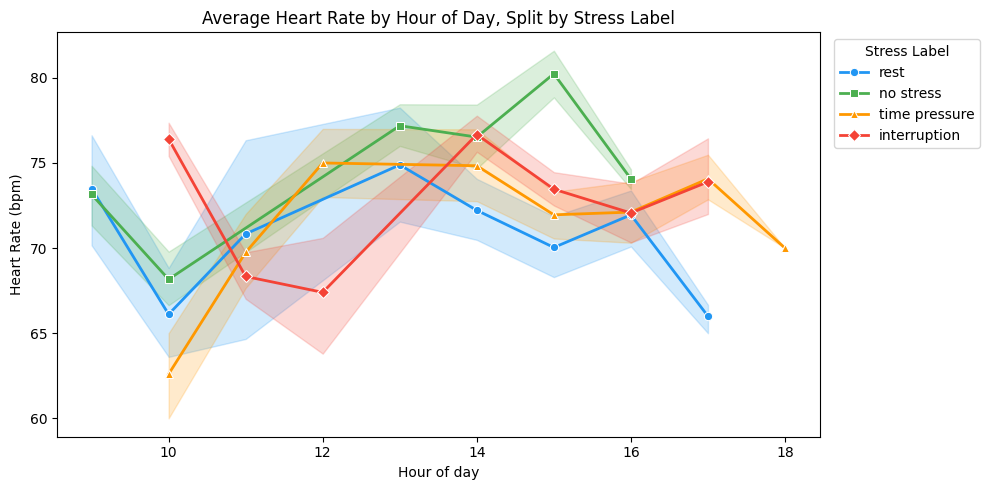

In [11]:
df = heart_rate_data_all.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["timestamp"] = df["timestamp"].fillna(df["date"])
df["hour"] = df["timestamp"].dt.hour

order = ["rest", "no stress", "time pressure", "interruption"]
palette = {"rest": "#2196F3", "no stress": "#4CAF50", "time pressure": "#FF9800", "interruption": "#F44336"}
markers = {"rest": "o", "no stress": "s", "time pressure": "^", "interruption": "D"}

plt.figure(figsize=(10,5))
sns.lineplot(
    data=df.dropna(subset=["HR"]),
    x="hour", y="HR",
    hue="label",
    hue_order=order,
    style="label",
    markers=markers,
    dashes=False,
    palette=palette,
    errorbar="ci",
    linewidth=2
)
plt.title("Average Heart Rate by Hour of Day, Split by Stress Label")
plt.xlabel("Hour of day")
plt.ylabel("Heart Rate (bpm)")
plt.legend(title="Stress Label", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### 2. Heart Rate by Label & Condition

C:\Users\DELL\AppData\Local\Temp\ipykernel_14292\150763734.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


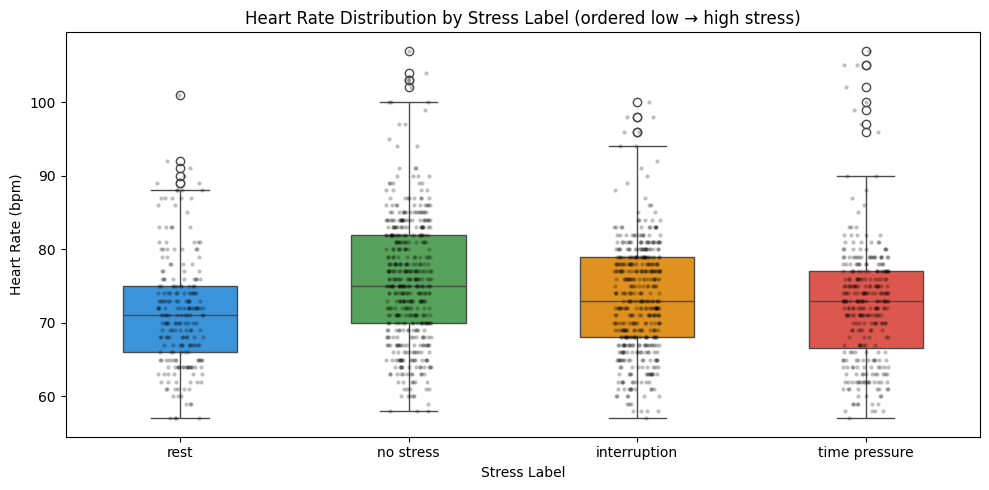

In [12]:
# heart rate by stress label — ordered from low to high stress
stress_order = ["rest", "no stress", "interruption", "time pressure"]
palette = {"rest": "#2196F3", "no stress": "#4CAF50", "interruption": "#FF9800", "time pressure": "#F44336"}

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=heart_rate_data_all.dropna(subset=["HR"]),
    x="label", y="HR",
    order=stress_order,
    palette=palette,
    width=0.5,
    ax=ax
)
sns.stripplot(
    data=heart_rate_data_all.dropna(subset=["HR"]),
    x="label", y="HR",
    order=stress_order,
    color="black", alpha=0.25, size=3, jitter=True, ax=ax
)
ax.set_title("Heart Rate Distribution by Stress Label (ordered low → high stress)")
ax.set_xlabel("Stress Label")
ax.set_ylabel("Heart Rate (bpm)")
plt.tight_layout()
plt.show()


#### 3. Heatmap Showing % of Observations that are "Stressed" (Time Pressure, Interruption) by Subject & Hour

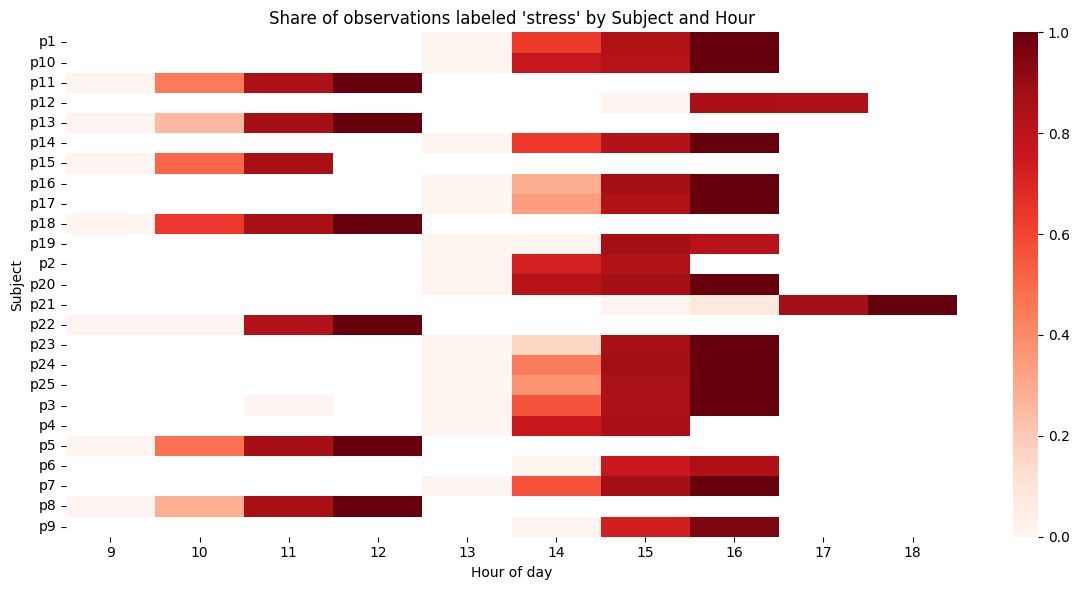

In [13]:
# make a copy of df
df = heart_rate_data_all.copy()

# make sure timestamp is in datetime format and extract the hour
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["timestamp"] = df["timestamp"].fillna(df["date"])
df["hour"] = df["timestamp"].dt.hour

# define what counts as "stressed" (time pressure & interruption)
stress_labels = ["time pressure", "interruption"]
df["is_stress"] = df["label"].isin(stress_labels)

# make heat map (share of observations labeled "stressed" by subject and hour)
heat = (df.groupby(["subject","hour"])["is_stress"]
          .mean()
          .reset_index()
          .pivot(index="subject", columns="hour", values="is_stress")
        )

# plot the heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heat, cmap="Reds", vmin=0, vmax=1)
plt.title("Share of observations labeled 'stress' by Subject and Hour")
plt.xlabel("Hour of day")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()

#### 4. RMSSD by Hour of Day & Label

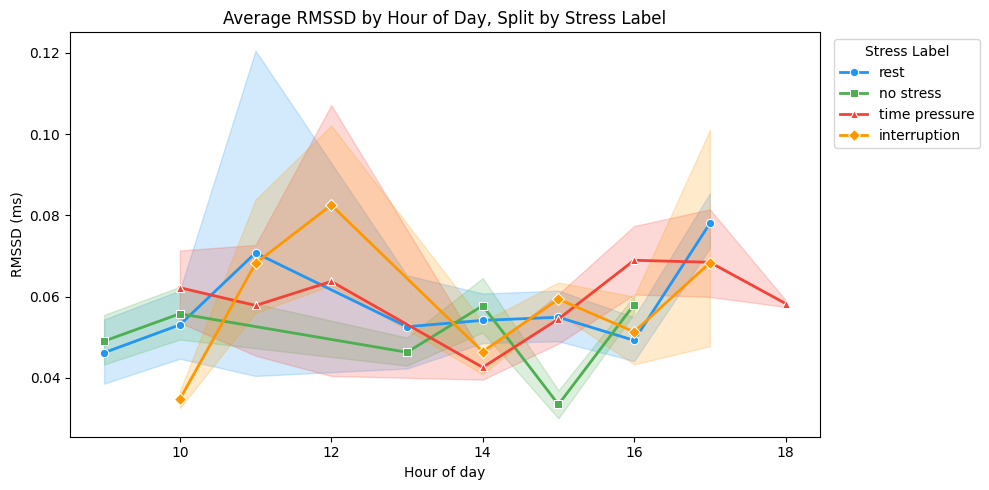

In [14]:
df = heart_rate_data_all.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["timestamp"] = df["timestamp"].fillna(df["date"])
df["hour"] = df["timestamp"].dt.hour

order = ["rest", "no stress", "time pressure", "interruption"]
palette = {"rest": "#2196F3", "no stress": "#4CAF50", "interruption": "#FF9800", "time pressure": "#F44336"}
markers = {"rest": "o", "no stress": "s", "time pressure": "^", "interruption": "D"}

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df.dropna(subset=["RMSSD"]),
    x="hour", y="RMSSD",
    hue="label",
    hue_order=order,
    style="label",
    markers=markers,
    dashes=False,
    palette=palette,
    errorbar="ci",
    linewidth=2
)
plt.title("Average RMSSD by Hour of Day, Split by Stress Label")
plt.xlabel("Hour of day")
plt.ylabel("RMSSD (ms)")
plt.legend(title="Stress Label", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### 5. RMSSD Distribution by Stress Label

C:\Users\DELL\AppData\Local\Temp\ipykernel_14292\3214751561.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


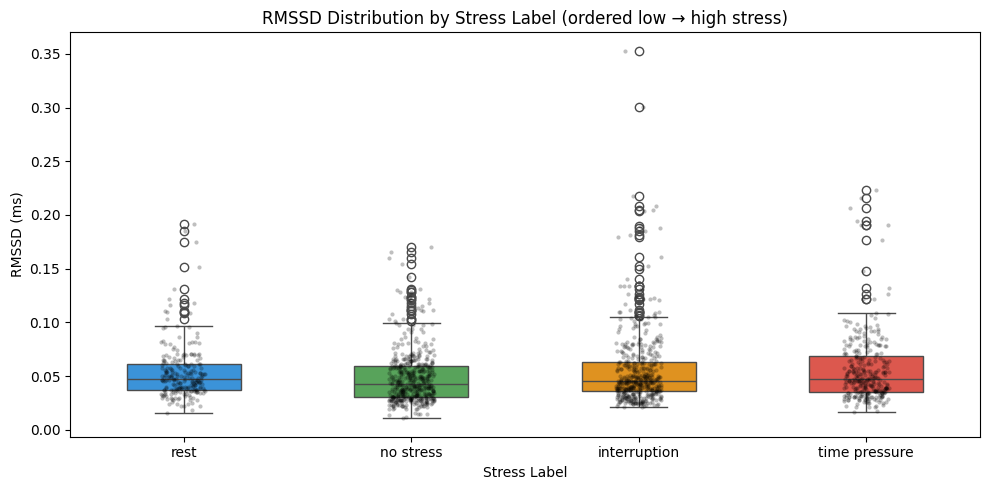

In [15]:
stress_order = ["rest", "no stress", "interruption", "time pressure"]
palette = {"rest": "#2196F3", "no stress": "#4CAF50", "interruption": "#FF9800", "time pressure": "#F44336"}

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=heart_rate_data_all.dropna(subset=["RMSSD"]),
    x="label", y="RMSSD",
    order=stress_order,
    palette=palette,
    width=0.5,
    ax=ax
)
sns.stripplot(
    data=heart_rate_data_all.dropna(subset=["RMSSD"]),
    x="label", y="RMSSD",
    order=stress_order,
    color="black", alpha=0.25, size=3, jitter=True, ax=ax
)
ax.set_title("RMSSD Distribution by Stress Label (ordered low → high stress)")
ax.set_xlabel("Stress Label")
ax.set_ylabel("RMSSD (ms)")
plt.tight_layout()
plt.show()


#### 6. SCL by Hour of Day & Label

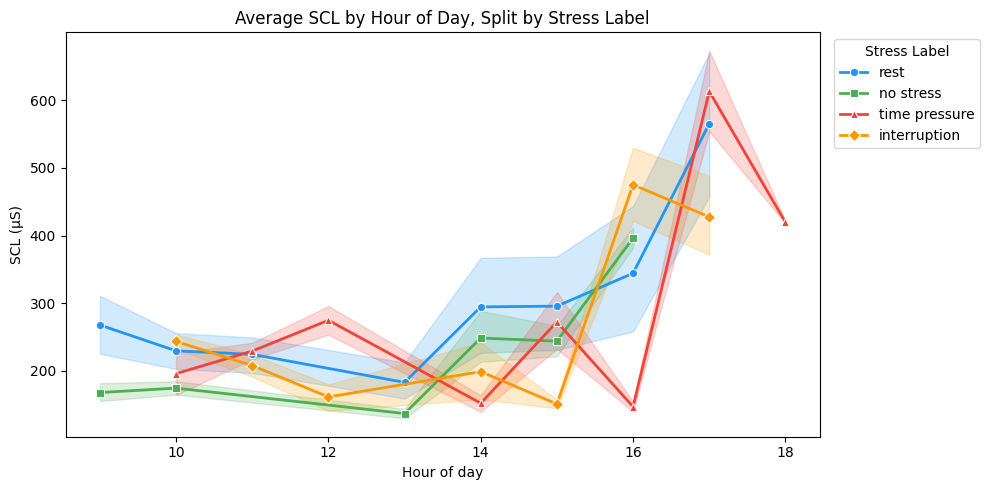

In [16]:
df = heart_rate_data_all.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["timestamp"] = df["timestamp"].fillna(df["date"])
df["hour"] = df["timestamp"].dt.hour

order = ["rest", "no stress", "time pressure", "interruption"]
palette = {"rest": "#2196F3", "no stress": "#4CAF50", "interruption": "#FF9800", "time pressure": "#F44336"}
markers = {"rest": "o", "no stress": "s", "time pressure": "^", "interruption": "D"}

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df.dropna(subset=["SCL"]),
    x="hour", y="SCL",
    hue="label",
    hue_order=order,
    style="label",
    markers=markers,
    dashes=False,
    palette=palette,
    errorbar="ci",
    linewidth=2
)
plt.title("Average SCL by Hour of Day, Split by Stress Label")
plt.xlabel("Hour of day")
plt.ylabel("SCL (µS)")
plt.legend(title="Stress Label", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### 7. SCL Distribution by Stress Label

C:\Users\DELL\AppData\Local\Temp\ipykernel_14292\2109099084.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


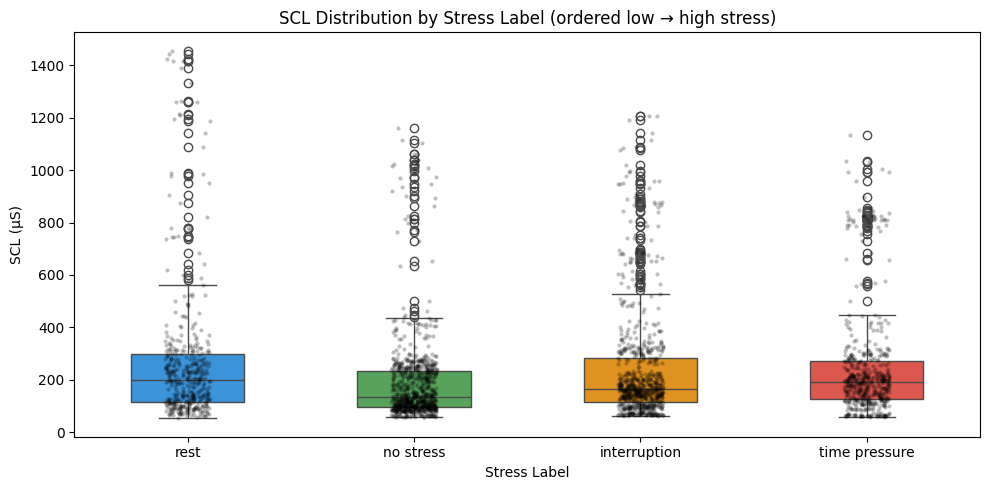

In [17]:
stress_order = ["rest", "no stress", "interruption", "time pressure"]
palette = {"rest": "#2196F3", "no stress": "#4CAF50", "interruption": "#FF9800", "time pressure": "#F44336"}

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=heart_rate_data_all.dropna(subset=["SCL"]),
    x="label", y="SCL",
    order=stress_order,
    palette=palette,
    width=0.5,
    ax=ax
)
sns.stripplot(
    data=heart_rate_data_all.dropna(subset=["SCL"]),
    x="label", y="SCL",
    order=stress_order,
    color="black", alpha=0.25, size=3, jitter=True, ax=ax
)
ax.set_title("SCL Distribution by Stress Label (ordered low → high stress)")
ax.set_xlabel("Stress Label")
ax.set_ylabel("SCL (µS)")
plt.tight_layout()
plt.show()
